# Notebook 08 - Model Evaluation

**Comprehensive evaluation of the DenseNet121 model on the test set.**

## Objectives

1. Load the trained DenseNet121 model (deployed in Streamlit)
2. Run inference on the full test set (16,491 images)
3. Generate ROC curves for all 14 disease classes
4. Create precision-recall curves
5. Compute per-disease performance metrics
6. Analyze error cases (false positives/negatives)
7. Compare with baseline models
8. Save visualizations for Streamlit integration

## Outputs

- ROC curves (interactive Plotly + static PNG)
- Precision-Recall curves
- Per-disease confusion matrices
- Detailed performance metrics (JSON)
- Error analysis report

---

## 1. Setup and Configuration

In [8]:
# Standard library imports
import os
import json
from pathlib import Path
from datetime import datetime

# Data handling
import numpy as np
import pandas as pd
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine learning
from sklearn.metrics import (
    roc_curve, auc, 
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)

# Deep learning
import tensorflow as tf
from tensorflow import keras

# Progress bars
from tqdm.auto import tqdm

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.18.1
Keras version: 3.12.0


In [9]:
# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Find project root (directory containing jupyter_notebooks/)
# This works regardless of where the notebook is executed from
import os
if 'jupyter_notebooks' in os.getcwd():
    # Running from within jupyter_notebooks/
    PROJECT_ROOT = Path(os.getcwd()).parent
else:
    # Running from project root
    PROJECT_ROOT = Path(os.getcwd())

print(f"Current working directory: {os.getcwd()}")
print(f"Project root: {PROJECT_ROOT}")

# Paths
MODEL_PATH = PROJECT_ROOT / 'models' / 'saved_models' / 'densenet121_best.keras'
TEST_SPLIT_CSV = PROJECT_ROOT / 'data' / 'processed' / 'test_split.csv'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures' / 'evaluation'
REPORTS_DIR = OUTPUTS_DIR / 'reports'

# Verify paths exist
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")
if not TEST_SPLIT_CSV.exists():
    raise FileNotFoundError(f"Test split not found at {TEST_SPLIT_CSV}")

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Disease classes (14 conditions)
DISEASE_CLASSES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

# Model parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ImageNet normalization (same as training)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

print(f"\n✅ Configuration complete")
print(f"   Model path: {MODEL_PATH.name}")
print(f"   Test split: {TEST_SPLIT_CSV.name}")
print(f"   Disease classes: {len(DISEASE_CLASSES)}")

Current working directory: /Volumes/SSD/Capstone
Project root: /Volumes/SSD/Capstone

✅ Configuration complete
   Model path: densenet121_best.keras
   Test split: test_split.csv
   Disease classes: 14


## 2. Load Model and Test Data

In [10]:
# Load the trained DenseNet121 model
print("Loading DenseNet121 model...")
model = keras.models.load_model(MODEL_PATH)

print("\nModel Summary:")
print(f"Input shape: {model.input_shape}")
print(f"Output shape: {model.output_shape}")
print(f"Total parameters: {model.count_params():,}")

# Display model architecture
model.summary()

Loading DenseNet121 model...


2025-11-06 10:09:59.095397: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-11-06 10:09:59.095811: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-06 10:09:59.095816: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1762423799.097030 32407797 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1762423799.098042 32407797 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Volumes/SSD/Capstone/.venv/lib/python3.11/site-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(



Model Summary:
Input shape: (None, 224, 224, 3)
Output shape: (None, 14)
Total parameters: 7,569,486


Model: "densenet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 14)             │         7,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,367,788 (35.74 MB)

 Trainable params: 899,150 (3.43 MB)

 Non-trainable params: 6,670,336 (25.45 MB)

 Optimizer params: 1,798,302 (6.86 MB)

In [11]:
# Load test split CSV
print("Loading test split metadata...")

if not TEST_SPLIT_CSV.exists():
    raise FileNotFoundError(f"Test split CSV not found at {TEST_SPLIT_CSV}. Run notebook 03 first.")

test_df = pd.read_csv(TEST_SPLIT_CSV)
print(f"✅ Loaded metadata for {len(test_df):,} test images")
print(f"\nColumns: {test_df.columns.tolist()[:10]}...")  # Show first 10 columns
print(f"\nDisease label columns:")
for disease in DISEASE_CLASSES:
    if disease in test_df.columns:
        n_positive = test_df[disease].sum()
        print(f"  {disease:20}: {n_positive:5d} positive ({n_positive/len(test_df)*100:.1f}%)")

print(f"\nFirst few rows:")
display(test_df[['Image Index', 'full_path'] + DISEASE_CLASSES].head())

Loading test split metadata...
✅ Loaded metadata for 16,890 test images

Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x']...

Disease label columns:
  Atelectasis         :  1698 positive (10.1%)
  Cardiomegaly        :   505 positive (3.0%)
  Effusion            :  2064 positive (12.2%)
  Infiltration        :  3179 positive (18.8%)
  Mass                :   899 positive (5.3%)
  Nodule              :   979 positive (5.8%)
  Pneumonia           :   495 positive (2.9%)
  Pneumothorax        :   794 positive (4.7%)
  Consolidation       :  1015 positive (6.0%)
  Edema               :   626 positive (3.7%)
  Emphysema           :   361 positive (2.1%)
  Fibrosis            :   251 positive (1.5%)
  Pleural_Thickening  :   468 positive (2.8%)
  Hernia              :    47 positive (0.3%)

First few rows:


,Image Index,full_path,Atelectasis,Cardiomegaly,Effusion,Infiltration,Mass,Nodule,Pneumonia,Pneumothorax,Consolidation,Edema,Emphysema,Fibrosis,Pleural_Thickening,Hernia
0,00000007_000.png,/Volumes/SSD/Capstone/data/raw/images_001/imag...,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00000008_000.png,/Volumes/SSD/Capstone/data/raw/images_001/imag...,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,00000008_001.png,/Volumes/SSD/Capstone/data/raw/images_001/imag...,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,00000008_002.png,/Volumes/SSD/Capstone/data/raw/images_001/imag...,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,00000035_000.png,/Volumes/SSD/Capstone/data/raw/images_001/imag...,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
# Create custom data generator from CSV
print("Creating data generator from CSV...")

def preprocess_image(img_path):
    """Load and preprocess image for DenseNet121."""
    # Load image
    img = Image.open(img_path).convert('RGB')
    
    # Resize
    img = img.resize(IMG_SIZE, Image.LANCZOS)
    
    # Convert to array and normalize to [0, 1]
    img_array = np.array(img, dtype=np.float32) / 255.0
    
    # Apply ImageNet normalization
    img_array = (img_array - IMAGENET_MEAN) / IMAGENET_STD
    
    return img_array

def data_generator(df, batch_size=32):
    """Generator that yields batches of (images, labels)."""
    num_samples = len(df)
    
    while True:  # Loop forever for Keras fit
        for offset in range(0, num_samples, batch_size):
            batch_df = df.iloc[offset:offset+batch_size]
            
            # Load and preprocess images
            images = []
            for img_path in batch_df['full_path']:
                try:
                    img = preprocess_image(img_path)
                    images.append(img)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    # Use zeros as placeholder for failed images
                    images.append(np.zeros((*IMG_SIZE, 3), dtype=np.float32))
            
            # Get labels
            labels = batch_df[DISEASE_CLASSES].values.astype(np.float32)
            
            yield np.array(images), labels

# Calculate number of batches
num_batches = int(np.ceil(len(test_df) / BATCH_SIZE))

print(f"✅ Data generator created")
print(f"   Total samples: {len(test_df):,}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Number of batches: {num_batches}")
print(f"   Images per batch (last): {len(test_df) % BATCH_SIZE or BATCH_SIZE}")

Creating data generator from CSV...
✅ Data generator created
   Total samples: 16,890
   Batch size: 32
   Number of batches: 528
   Images per batch (last): 26


## 3. Run Inference on Test Set

Generate predictions for all test images.

In [13]:
# Run predictions on test set
print("Running inference on test set...")
print(f"This will process {len(test_df):,} images in {num_batches} batches")
print("Estimated time: ~30-45 minutes on CPU\n")

# Create generator instance
test_generator = data_generator(test_df, batch_size=BATCH_SIZE)

# Get predictions
y_pred = model.predict(
    test_generator,
    steps=num_batches,
    verbose=1
)

print(f"\nPredictions shape: {y_pred.shape}")
print(f"Expected shape: ({len(test_df)}, {len(DISEASE_CLASSES)})")

# Get true labels from dataframe
y_true = test_df[DISEASE_CLASSES].values.astype(np.float32)
print(f"True labels shape: {y_true.shape}")

# Verify shapes match
assert y_pred.shape[0] == y_true.shape[0], f"Prediction count ({y_pred.shape[0]}) != label count ({y_true.shape[0]})!"
assert y_pred.shape[1] == len(DISEASE_CLASSES), f"Predicted classes ({y_pred.shape[1]}) != expected ({len(DISEASE_CLASSES)})!"

print("\n✅ Inference complete!")

Running inference on test set...
This will process 16,890 images in 528 batches
Estimated time: ~30-45 minutes on CPU



2025-11-06 10:10:03.943741: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


528/528 ━━━━━━━━━━━━━━━━━━━━ 422s 792ms/step

Predictions shape: (16890, 14)
Expected shape: (16890, 14)
True labels shape: (16890, 14)

✅ Inference complete!


In [14]:
# Save predictions for future use
predictions_path = REPORTS_DIR / 'densenet121_test_predictions.npz'
np.savez_compressed(
    predictions_path,
    y_pred=y_pred,
    y_true=y_true,
    disease_classes=DISEASE_CLASSES
)
print(f"Predictions saved to: {predictions_path}")
print(f"File size: {predictions_path.stat().st_size / (1024*1024):.2f} MB")

Predictions saved to: /Volumes/SSD/Capstone/outputs/reports/densenet121_test_predictions.npz
File size: 0.86 MB


## 4. Generate ROC Curves

Create ROC curves for each disease class.

In [15]:
# Calculate ROC curves for all diseases
print("Calculating ROC curves for all diseases...\n")

roc_data = {}

for i, disease in enumerate(DISEASE_CLASSES):
    # Get true labels and predictions for this disease
    y_true_disease = y_true[:, i]
    y_pred_disease = y_pred[:, i]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true_disease, y_pred_disease)
    roc_auc = auc(fpr, tpr)
    
    # Store data
    roc_data[disease] = {
        'fpr': fpr.tolist(),
        'tpr': tpr.tolist(),
        'thresholds': thresholds.tolist(),
        'auc': float(roc_auc),
        'n_positive': int(y_true_disease.sum()),
        'n_negative': int((1 - y_true_disease).sum())
    }
    
    print(f"{disease:20} - AUC: {roc_auc:.4f} (pos: {roc_data[disease]['n_positive']:5d}, neg: {roc_data[disease]['n_negative']:5d})")

# Calculate average AUC
avg_auc = np.mean([data['auc'] for data in roc_data.values()])
print(f"\nAverage AUC across all diseases: {avg_auc:.4f}")

Calculating ROC curves for all diseases...

Atelectasis          - AUC: 0.7070 (pos:  1698, neg: 15192)
Cardiomegaly         - AUC: 0.7140 (pos:   505, neg: 16385)
Effusion             - AUC: 0.7551 (pos:  2064, neg: 14826)
Infiltration         - AUC: 0.6550 (pos:  3179, neg: 13711)
Mass                 - AUC: 0.6110 (pos:   899, neg: 15991)
Nodule               - AUC: 0.5975 (pos:   979, neg: 15911)
Pneumonia            - AUC: 0.3723 (pos:   495, neg: 16395)
Pneumothorax         - AUC: 0.6190 (pos:   794, neg: 16096)
Consolidation        - AUC: 0.7359 (pos:  1015, neg: 15875)
Edema                - AUC: 0.4954 (pos:   626, neg: 16264)
Emphysema            - AUC: 0.5176 (pos:   361, neg: 16529)
Fibrosis             - AUC: 0.6845 (pos:   251, neg: 16639)
Pleural_Thickening   - AUC: 0.5669 (pos:   468, neg: 16422)
Hernia               - AUC: 0.4532 (pos:    47, neg: 16843)

Average AUC across all diseases: 0.6060


In [16]:
# Save ROC data to JSON
roc_json_path = REPORTS_DIR / 'roc_curves_densenet121.json'
with open(roc_json_path, 'w') as f:
    json.dump(roc_data, f, indent=2)
print(f"ROC data saved to: {roc_json_path}")

ROC data saved to: /Volumes/SSD/Capstone/outputs/reports/roc_curves_densenet121.json


### 4.1 Plot Individual ROC Curves

Creating individual ROC curve plots...

Saved: /Volumes/SSD/Capstone/outputs/figures/evaluation/roc_curves_all_diseases.png


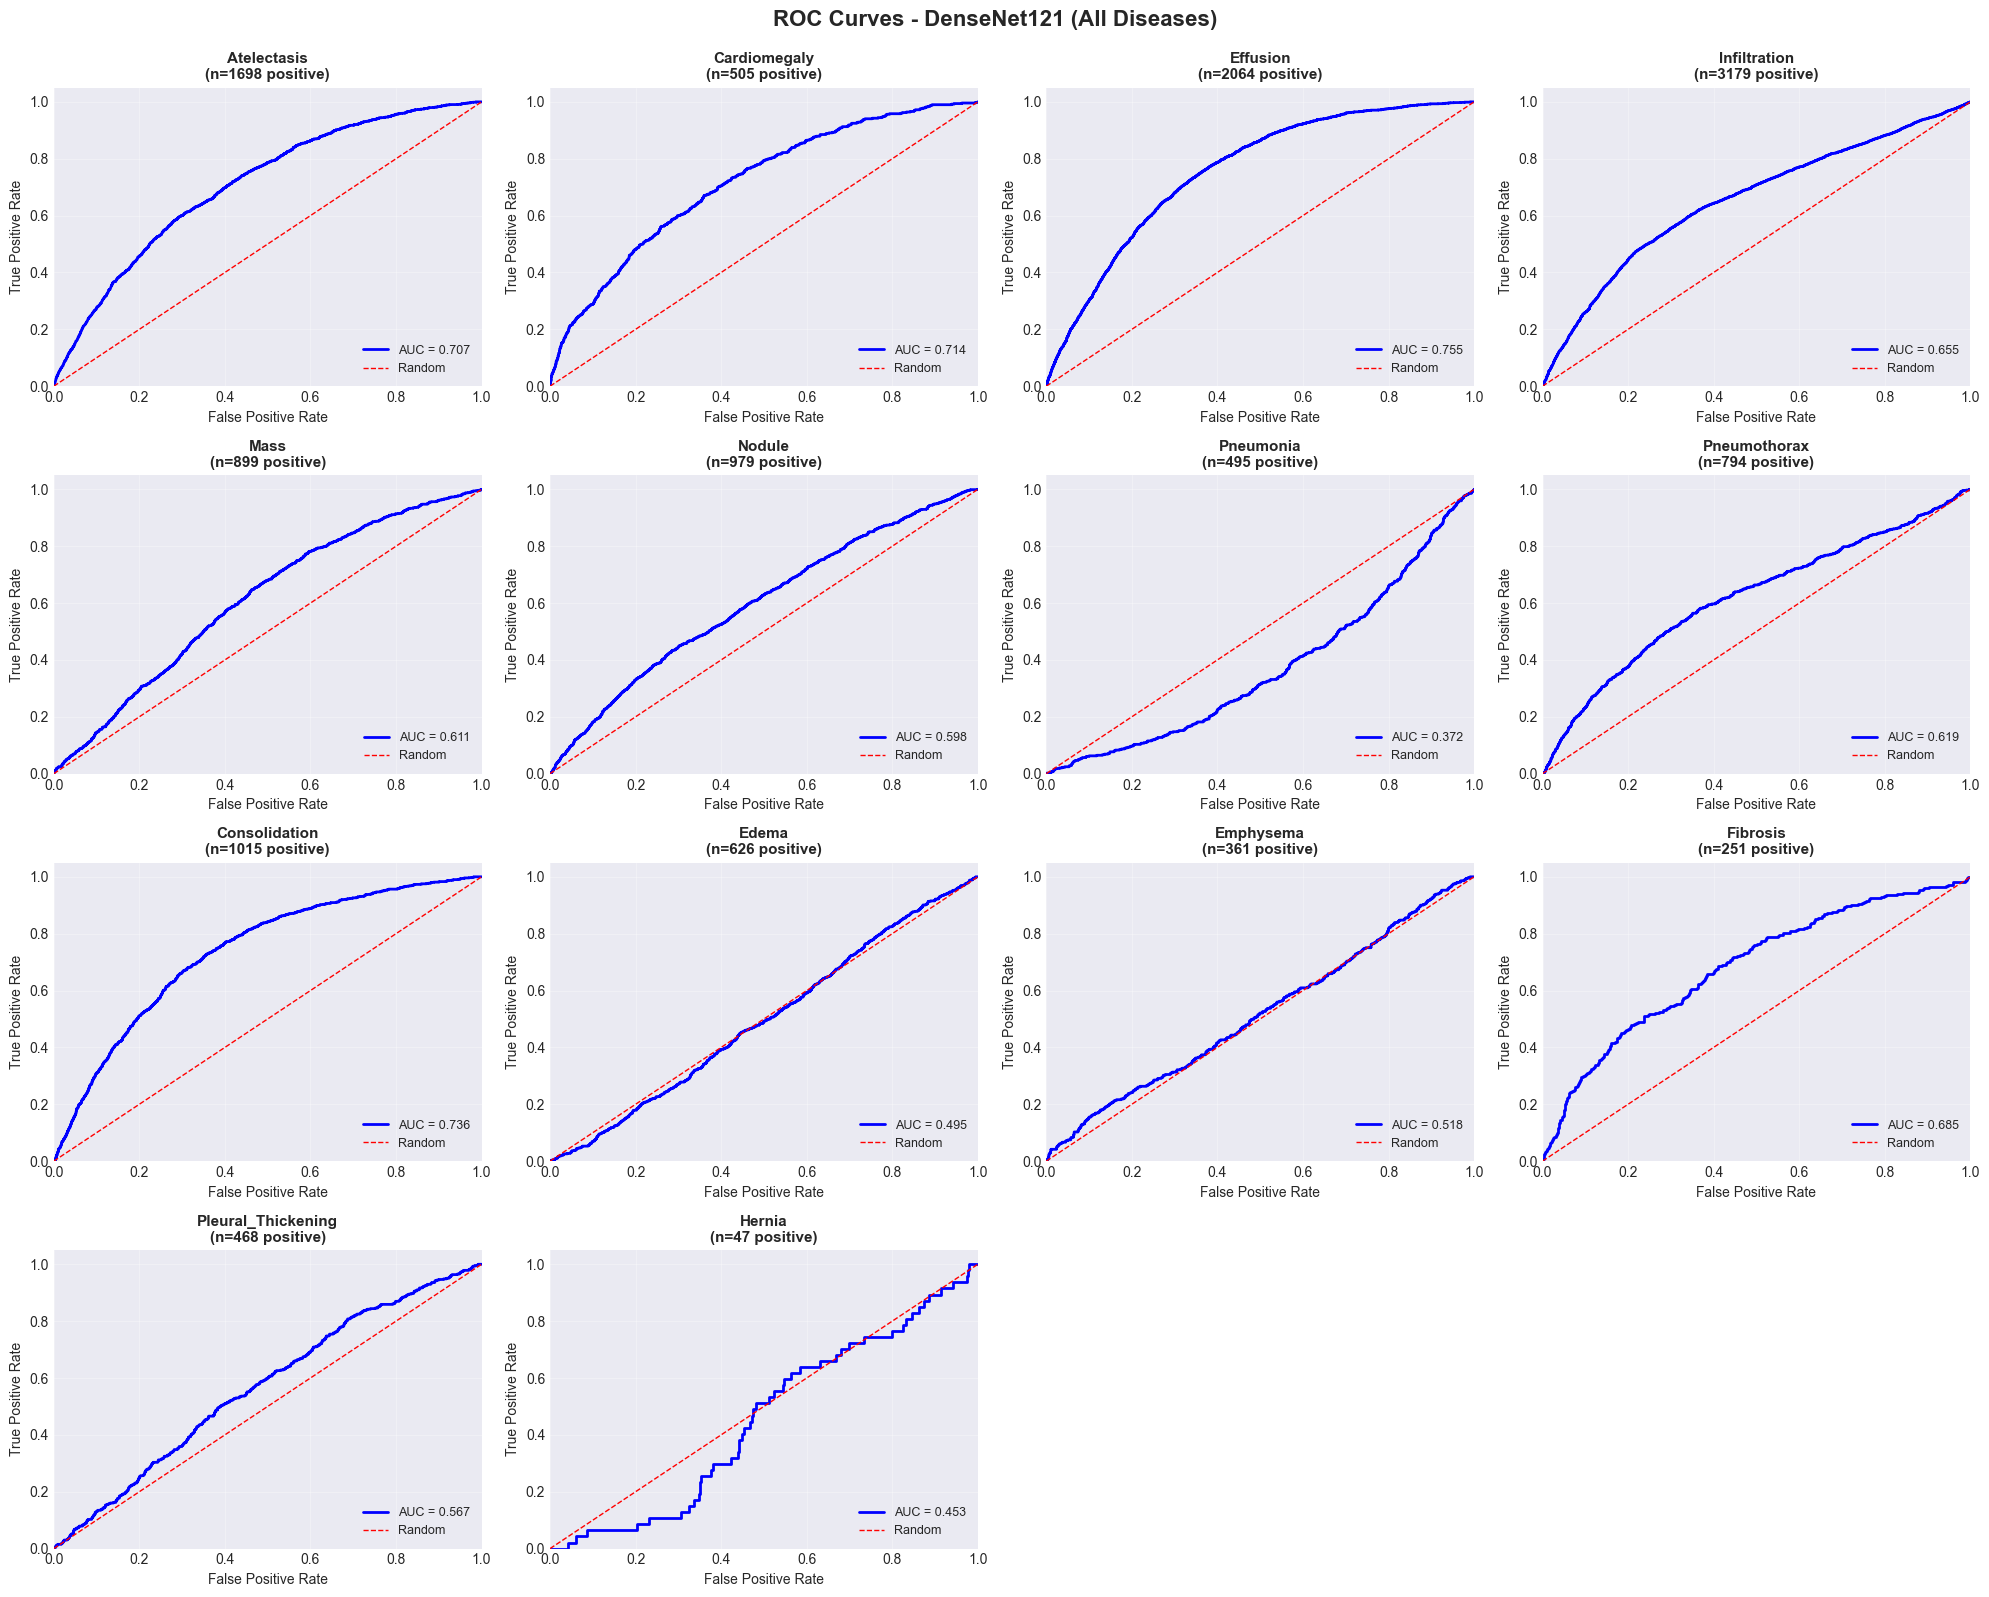

In [17]:
# Create individual ROC curve plots
print("Creating individual ROC curve plots...\n")

# Set up matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, (disease, data) in enumerate(roc_data.items()):
    ax = axes[i]
    
    # Plot ROC curve
    ax.plot(data['fpr'], data['tpr'], 'b-', linewidth=2, label=f'AUC = {data["auc"]:.3f}')
    
    # Plot diagonal (random classifier)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'{disease}\n(n={data["n_positive"]} positive)', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide extra subplots if needed
for i in range(len(DISEASE_CLASSES), len(axes)):
    axes[i].axis('off')

plt.suptitle('ROC Curves - DenseNet121 (All Diseases)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

# Save figure
roc_png_path = FIGURES_DIR / 'roc_curves_all_diseases.png'
plt.savefig(roc_png_path, dpi=150, bbox_inches='tight')
print(f"Saved: {roc_png_path}")

plt.show()

### 4.2 Interactive ROC Curves (Plotly)

In [18]:
# Create interactive Plotly visualization
print("Creating interactive ROC curves (Plotly)...\n")

# Option 1: All diseases on one plot
fig_all = go.Figure()

# Add ROC curve for each disease
for disease, data in roc_data.items():
    fig_all.add_trace(go.Scatter(
        x=data['fpr'],
        y=data['tpr'],
        mode='lines',
        name=f"{disease} (AUC={data['auc']:.3f})",
        hovertemplate=f'<b>{disease}</b><br>' +
                      'FPR: %{x:.3f}<br>' +
                      'TPR: %{y:.3f}<br>' +
                      '<extra></extra>'
    ))

# Add diagonal reference line
fig_all.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random Classifier',
    line=dict(color='red', width=2, dash='dash'),
    showlegend=True
))

fig_all.update_layout(
    title='ROC Curves - DenseNet121 (All Diseases)',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    width=1000,
    height=700,
    hovermode='closest',
    legend=dict(
        yanchor="bottom",
        y=0.01,
        xanchor="right",
        x=0.99
    )
)

# Save interactive HTML
roc_html_path = FIGURES_DIR / 'roc_curves_interactive.html'
fig_all.write_html(roc_html_path)
print(f"Saved: {roc_html_path}")

fig_all.show()

Creating interactive ROC curves (Plotly)...

Saved: /Volumes/SSD/Capstone/outputs/figures/evaluation/roc_curves_interactive.html


In [19]:
# Option 2: Individual interactive plots for each disease
print("Creating individual interactive ROC curves...\n")

for disease, data in roc_data.items():
    fig = go.Figure()
    
    # ROC curve
    fig.add_trace(go.Scatter(
        x=data['fpr'],
        y=data['tpr'],
        mode='lines',
        name=f'{disease} (AUC = {data["auc"]:.3f})',
        line=dict(color='blue', width=3),
        fill='tozeroy',
        fillcolor='rgba(0, 100, 255, 0.2)'
    ))
    
    # Diagonal
    fig.add_trace(go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode='lines',
        name='Random',
        line=dict(color='red', width=2, dash='dash')
    ))
    
    fig.update_layout(
        title=f'ROC Curve - {disease}<br><sub>{data["n_positive"]} positive cases, {data["n_negative"]} negative cases</sub>',
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        width=700,
        height=600,
        hovermode='x unified'
    )
    
    # Save
    disease_safe = disease.replace(' ', '_').replace('/', '_')
    path = FIGURES_DIR / f'roc_{disease_safe.lower()}.html'
    fig.write_html(path)
    print(f"Saved: {path.name}")

Creating individual interactive ROC curves...

Saved: roc_atelectasis.html
Saved: roc_cardiomegaly.html
Saved: roc_effusion.html
Saved: roc_infiltration.html
Saved: roc_mass.html
Saved: roc_nodule.html
Saved: roc_pneumonia.html
Saved: roc_pneumothorax.html
Saved: roc_consolidation.html
Saved: roc_edema.html
Saved: roc_emphysema.html
Saved: roc_fibrosis.html
Saved: roc_pleural_thickening.html
Saved: roc_hernia.html


## 5. Summary

What we created in this notebook.

In [20]:
# Summary of generated files
print("=" * 60)
print("NOTEBOOK 08 - MODEL EVALUATION SUMMARY")
print("=" * 60)

print(f"\n📊 Model: DenseNet121")
print(f"Test samples: {y_pred.shape[0]:,}")
print(f"Disease classes: {len(DISEASE_CLASSES)}")
print(f"Average AUC: {avg_auc:.4f}")

print(f"\n📁 Generated Files:")
print(f"\nData:")
print(f"  - {predictions_path.name}")
print(f"  - {roc_json_path.name}")

print(f"\nVisualizations:")
figures_created = list(FIGURES_DIR.glob('*.png')) + list(FIGURES_DIR.glob('*.html'))
for fig_path in sorted(figures_created):
    size_mb = fig_path.stat().st_size / (1024*1024)
    print(f"  - {fig_path.name} ({size_mb:.2f} MB)")

print(f"\n✅ Evaluation complete!")
print(f"\n💡 Next steps:")
print(f"  1. Review ROC curves in: {FIGURES_DIR}")
print(f"  2. Integrate into Streamlit dashboard")
print(f"  3. Run error analysis (notebook 09)")

NOTEBOOK 08 - MODEL EVALUATION SUMMARY

📊 Model: DenseNet121
Test samples: 16,890
Disease classes: 14
Average AUC: 0.6060

📁 Generated Files:

Data:
  - densenet121_test_predictions.npz
  - roc_curves_densenet121.json

Visualizations:
  - roc_atelectasis.html (4.78 MB)
  - roc_cardiomegaly.html (4.65 MB)
  - roc_consolidation.html (4.68 MB)
  - roc_curves_all_diseases.png (0.45 MB)
  - roc_curves_interactive.html (5.57 MB)
  - roc_edema.html (4.66 MB)
  - roc_effusion.html (4.73 MB)
  - roc_emphysema.html (4.64 MB)
  - roc_fibrosis.html (4.63 MB)
  - roc_hernia.html (4.62 MB)
  - roc_infiltration.html (4.79 MB)
  - roc_mass.html (4.68 MB)
  - roc_nodule.html (4.68 MB)
  - roc_pleural_thickening.html (4.65 MB)
  - roc_pneumonia.html (4.65 MB)
  - roc_pneumothorax.html (4.67 MB)

✅ Evaluation complete!

💡 Next steps:
  1. Review ROC curves in: /Volumes/SSD/Capstone/outputs/figures/evaluation
  2. Integrate into Streamlit dashboard
  3. Run error analysis (notebook 09)
